In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv("heart.csv")
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1


In [3]:
df.isnull().sum().sum()

np.int64(0)

In [4]:
df.duplicated().sum().sum()

np.int64(1)

In [5]:
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [6]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum().sum()

np.int64(0)

In [11]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

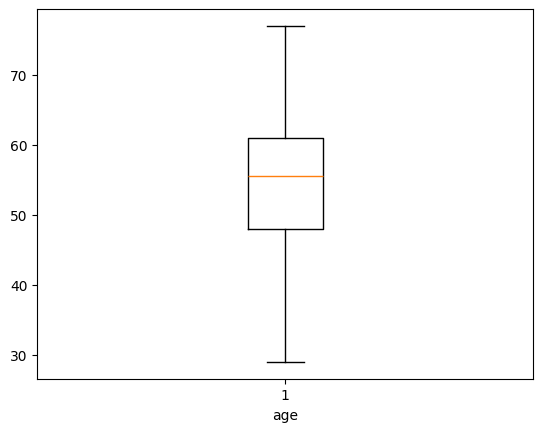

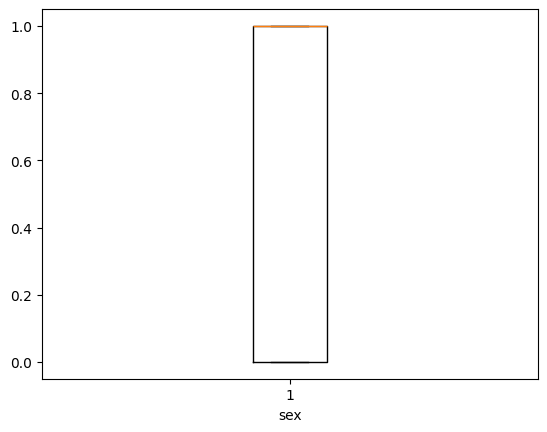

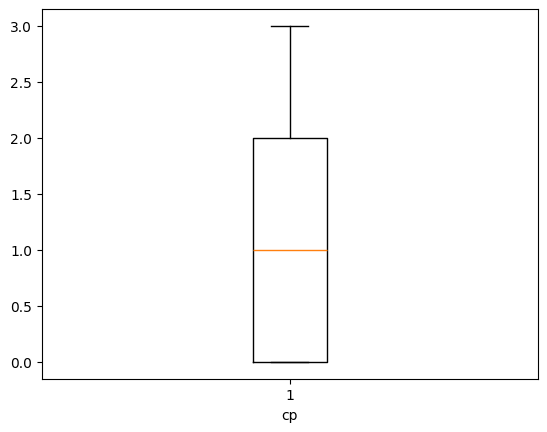

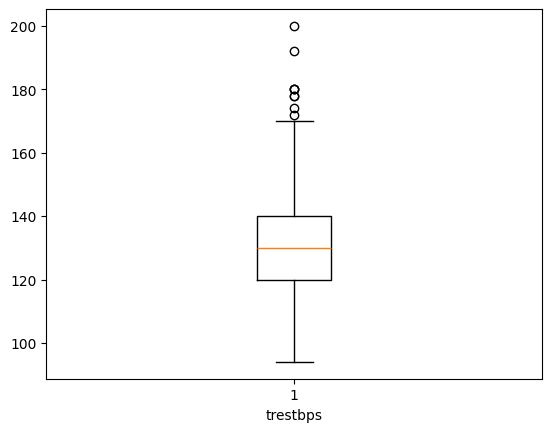

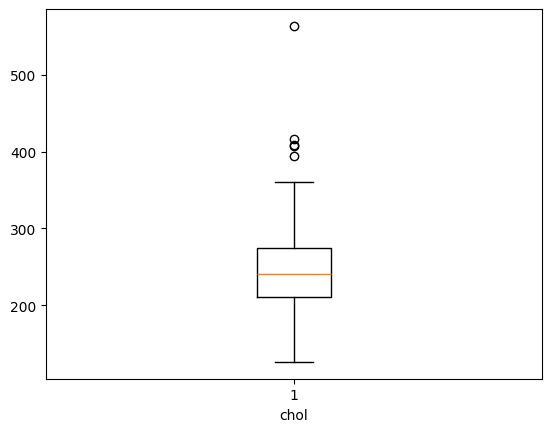

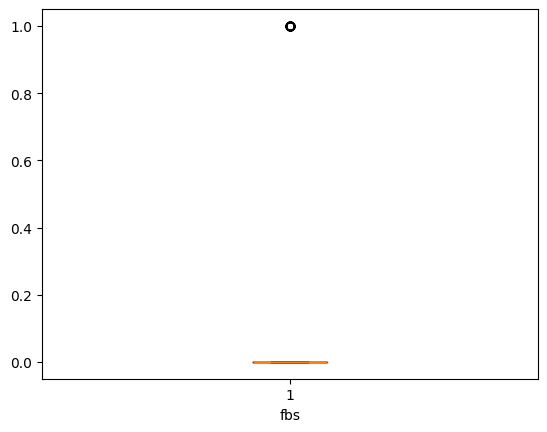

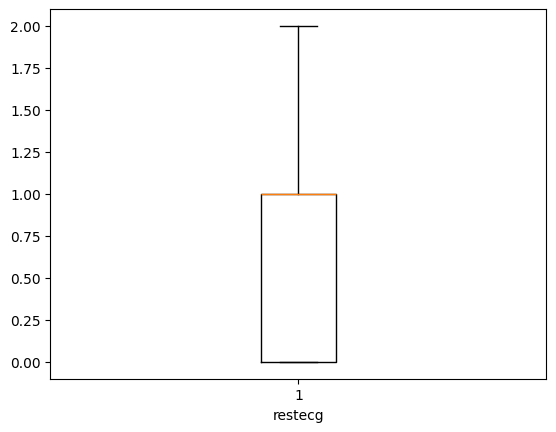

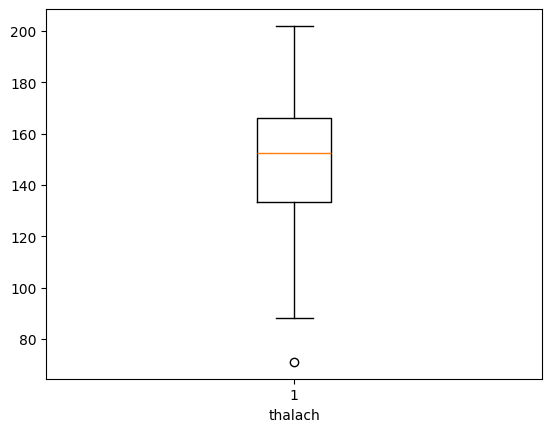

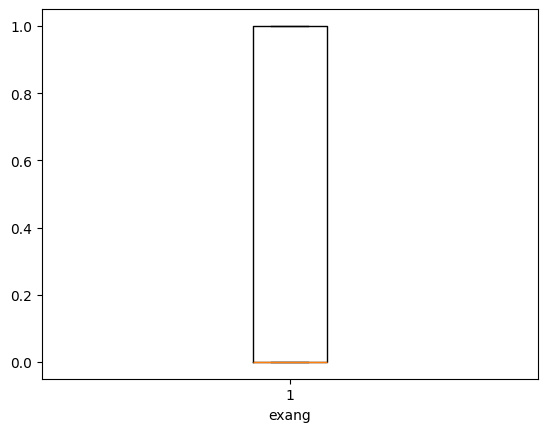

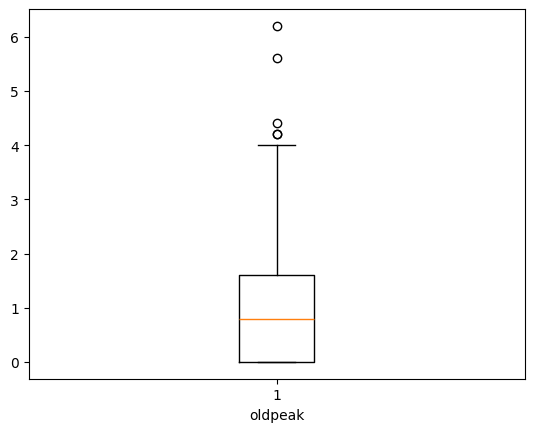

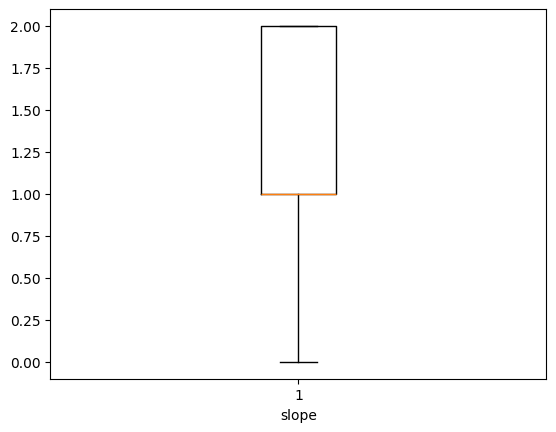

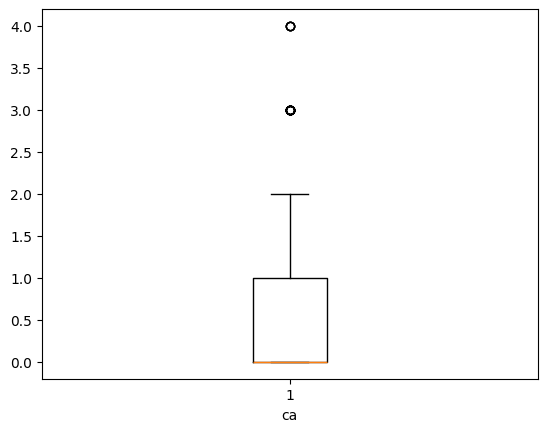

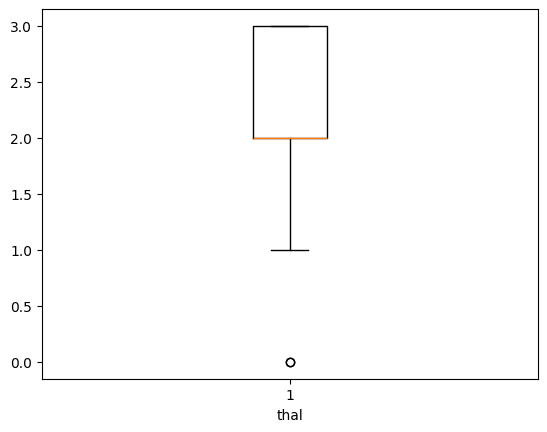

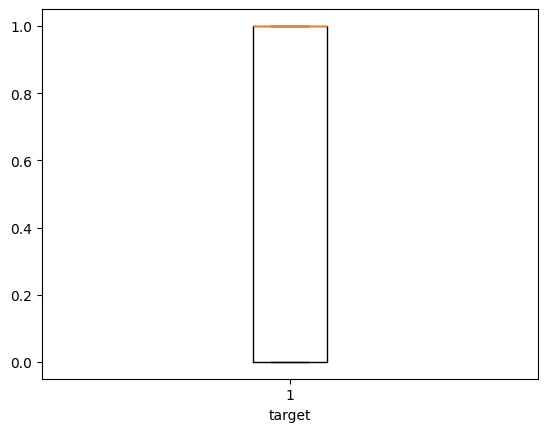

In [13]:
#outliers

for i in df.columns:
    if df[i].dtype!='object':
        plt.boxplot(df[i])
        plt.xlabel(i)
        plt.show()

In [15]:
cor=df.corr()

<Axes: >

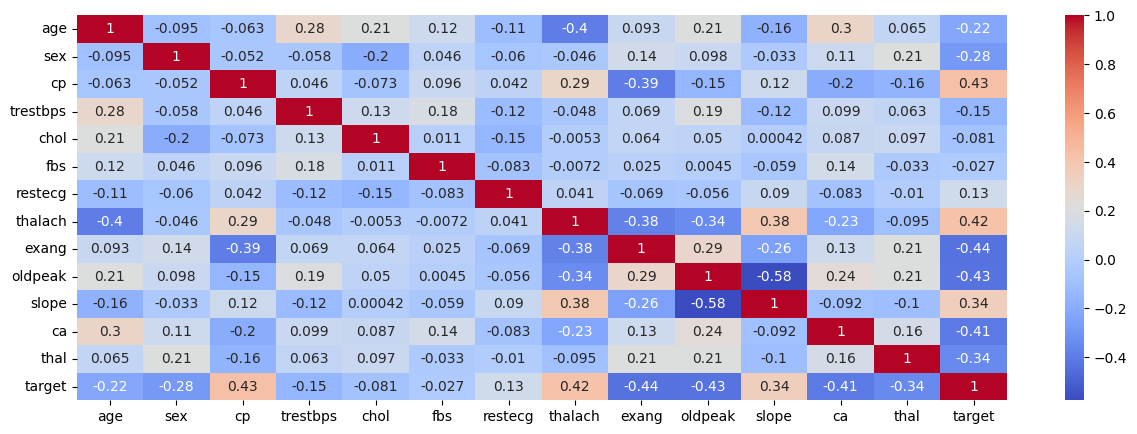

In [22]:
plt.figure(figsize=(15,5))
sns.heatmap(cor,annot=True,cmap='coolwarm')

In [23]:
#model building

In [24]:
x=df.drop(columns=['target'])
y=df['target']

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [27]:
from sklearn.tree import DecisionTreeClassifier

In [42]:
dtc=DecisionTreeClassifier(max_depth=5)
dtc.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [43]:
from sklearn import tree

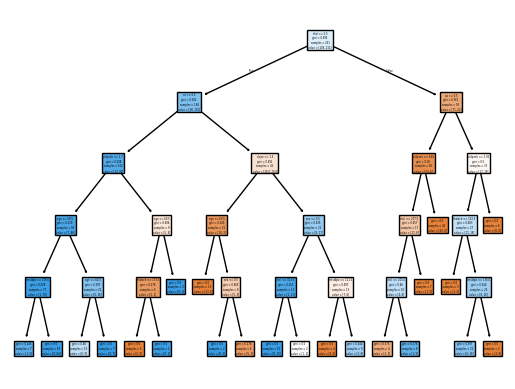

In [44]:
tree=tree.plot_tree(dtc,feature_names=x.columns,filled=True)

In [45]:
dtc.get_depth()

5

In [46]:
y_pred=dtc.predict(x_test)

In [47]:
from sklearn.metrics import accuracy_score,precision_score,recall_score

In [48]:
accuracy_score(y_test,y_pred)

0.819672131147541

In [49]:
# Checking For Overfitting Presenting in data

In [50]:
y_pred_train=dtc.predict(x_train)

In [51]:
accuracy_score(y_pred_train,y_train)

0.91701244813278